**6장 - 결정 트리**

**결정 트리(decision tree)** 는 분류와 회귀 작업 그리고 다중 출력 작업까지 가능한 다목적 머신러닝 알고리즘임. 또한 매우 복접한 데이터셋도 학습할 수 있는 알고리즘임.

# 설정

이 프로젝트를 실행하려면 파이썬 3.7 이상이 필요함:

In [2]:
import sys

assert sys.version_info >= (3, 7)

또한 사이킷런 1.0.1 이상이 필요함:

In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

기본 글꼴 크기를 정의함:

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

이미지를 저장할 경로와 함수를 정의함:

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_tree"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [6]:
from sklearn import set_config

set_config(display="text")

## 결정 트리 학습과 시각화

결정 트리를 이해하기 위해 모델 하나를 만들어 어떻게 예측을 하는지 확인.

DecisionTreeClassifier :

In [7]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

export_graphviz() 함수를 이용해 그래프 정의를 iris_tree.dot파일로 출력하여 훈련된 결정 트리르 시각화 할 수 있음.

In [10]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file=str(IMAGES_PATH / "iris_tree.dot"),
    feature_names=["petal length(cm)", "petal width(cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

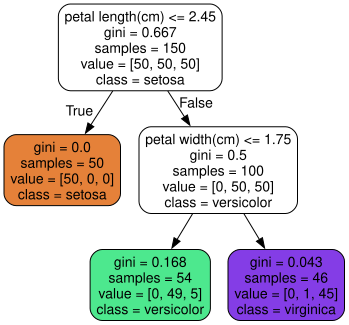

In [11]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree.dot")

Graphviz는 `.dot` 파일을 다양한 포맷으로 변환할 수 있는 'dot' 명령줄 도구도 제공함.

다음 명령어는 dot파일을 png 이미지로 변환

In [14]:
!dot -Tpng {IMAGES_PATH / "iris_tree.dot"} -o {IMAGES_PATH / "iris_tree.png"}